In [4]:
import numpy as np
from scipy.ndimage import binary_erosion, center_of_mass
import matplotlib.pyplot as plt
from pathlib import Path
import SimpleITK as sitk
from pathlib import Path

In [5]:
# === Settings ===
data_root = Path("data/LUNDPROBE/ExtendedSamples/development")
subject_index = 0
image_folder = "MR_StorT2"

# === Resolve case ===
case_name = sorted([p.name for p in data_root.iterdir() if p.is_dir()])[subject_index]
case_dir = data_root / case_name / image_folder

# === Paths ===
img_path = case_dir / "image.nii.gz"
mask_path = case_dir / "nnUNetOutput/mask_CTVT_427_nnUNet.nii.gz"
unc_path = case_dir / "nnUNetOutput/mask_CTVT_427_nnUNet_uncertaintyMap.nii.gz"

# === Load ===
img_itk = sitk.ReadImage(str(img_path))
mask_itk = sitk.ReadImage(str(mask_path))
unc_itk = sitk.ReadImage(str(unc_path))

img = sitk.GetArrayFromImage(img_itk)
pred_mask = sitk.GetArrayFromImage(mask_itk) > 0
uncertainty = sitk.GetArrayFromImage(unc_itk)

spacing_sitk = img_itk.GetSpacing()  # (x, y, z)
spacing = spacing_sitk[::-1]  # (z, y, x)

thresholded_unc = uncertainty > 0.0234  # adjust threshold as needed
sl = 38

print(case_name, img.shape)

newAcq_050f229dc2bdb64c (88, 1024, 1024)


In [6]:
def extract_bands(seg, unc_map):
    """
    Function that extracts:
    - seg_edge: the edge of the segmentation
    - unc_inner: the inner part of the uncertainty band (uncertainty pixels that are inside the segmentation, excluding the edge)
    - unc_outer: the outer part of the uncertainty band (uncertainty pixels that are outside the segmentation)
    - unc_edge_inner: the inner edge of the uncertainty band (uncertainty pixels on the inner edge of the segmentation)
    - unc_edge_outer: the outer edge of the uncertainty band (uncertainty pixels on the outer edge of the segmentation)
    """

    #Change maps into boolean for easier operations
    seg = seg.astype(bool)
    unc_map = unc_map.astype(bool)

    seg_edge = seg & ~binary_erosion(seg) #Finds edge of the segmentation by isolating eroded pixels

    unc_inner = unc_map & seg & ~seg_edge #Finds all uncertainty pixels on the inside of the segmentation, excluding the edge
    unc_outer = unc_map & ~seg #Finds all uncertainty pixels on the outside of the segmentation

    unc_band_edges = binary_erosion(unc_map)
    
    unc_edge_inner = (unc_inner & ~binary_erosion(unc_inner)) & ~unc_band_edges #Inner edge of the uncertainty band
    unc_edge_outer = (unc_outer & ~binary_erosion(unc_outer)) & ~unc_band_edges #Outer edge of the uncertainty

    return seg_edge, unc_inner, unc_outer, unc_edge_inner, unc_edge_outer

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact


def interactive_plot_bands(img, pred_mask, thresholded_unc, extract_bands, half=80):
    def overlay_color(mask, color, alpha=0.8):
        out = np.zeros((*mask.shape, 4), dtype=float)
        out[..., :3] = color
        out[..., 3] = mask.astype(float) * alpha
        return out

    def plot_slice(sl):
        seg_edge, unc_inner, unc_outer, unc_edge_inner, unc_edge_outer = extract_bands(
            pred_mask[sl], thresholded_unc[sl]
        )

        ys, xs = np.where(pred_mask[sl])

        if len(ys) > 0:
            cy, cx = int(np.mean(ys)), int(np.mean(xs))
            y0, y1 = max(0, cy - half), min(pred_mask.shape[1], cy + half)
            x0, x1 = max(0, cx - half), min(pred_mask.shape[2], cx + half)

            img_c = img[sl][y0:y1, x0:x1]
            seg_edge_c = seg_edge[y0:y1, x0:x1]
            unc_inner_c = unc_inner[y0:y1, x0:x1]
            unc_outer_c = unc_outer[y0:y1, x0:x1]
            unc_edge_inner_c = unc_edge_inner[y0:y1, x0:x1]
            unc_edge_outer_c = unc_edge_outer[y0:y1, x0:x1]
        else:
            img_c = img[sl]
            seg_edge_c = seg_edge
            unc_inner_c = unc_inner
            unc_outer_c = unc_outer
            unc_edge_inner_c = unc_edge_inner
            unc_edge_outer_c = unc_edge_outer

        vmin, vmax = np.percentile(img_c, [1, 99])

        plt.figure(figsize=(6, 6))
        plt.imshow(img_c, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        plt.imshow(overlay_color(seg_edge_c, [0, 1, 0], 0.9))        # green
        plt.imshow(overlay_color(unc_inner_c, [0, 0, 1], 0.3))       # blue
        plt.imshow(overlay_color(unc_outer_c, [1, 0, 0], 0.3))       # red
        plt.imshow(overlay_color(unc_edge_inner_c, [0, 1, 1], 1.0))  # cyan
        plt.imshow(overlay_color(unc_edge_outer_c, [1, 1, 0], 1.0))  # yellow
        plt.title(f"Bands + edges (slice {sl})")
        plt.axis("off")
        plt.show()

    interact(plot_slice, sl=(0, img.shape[0] - 1))

In [8]:
interactive_plot_bands(img, pred_mask, thresholded_unc, extract_bands, half=80)

interactive(children=(IntSlider(value=43, description='sl', max=87), Output()), _dom_classes=('widget-interact…

In [6]:
def raycast_band_lengths_mm(
    seg,
    unc_map,
    unc_inner,
    seg_edge,
    unc_outer,
    pixel_spacing=(1.0, 1.0),
    angle_step=1,
    step_mm=None,
    pad=5,
    debug_dir=None,
    background_image=None,
    figsize=(6, 6),
):
    seg = seg.astype(bool)
    unc_map = unc_map.astype(bool)
    unc_inner = unc_inner.astype(bool)
    seg_edge = seg_edge.astype(bool)
    unc_outer = unc_outer.astype(bool)

    spacing_y = pixel_spacing[1]
    spacing_x = pixel_spacing[2]

    if not seg.any():
        raise ValueError("Segmentation is empty.")

    if not unc_map.any():
        raise ValueError("Uncertainty map is empty.")

    if step_mm is None:
        step_mm = min(spacing_y, spacing_x) / 4.0

    cy, cx = center_of_mass(seg)
    h, w = seg.shape

    ys, xs = np.where(unc_map)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    cy_box = (y_min + y_max) / 2
    cx_box = (x_min + x_max) / 2

    half_size = max(y_max - y_min, x_max - x_min) / 2
    half_size = int(np.ceil(half_size)) + pad

    y0 = max(0, int(np.floor(cy_box - half_size)))
    y1 = min(h, int(np.ceil(cy_box + half_size + 1)))
    x0 = max(0, int(np.floor(cx_box - half_size)))
    x1 = min(w, int(np.ceil(cx_box + half_size + 1)))

    # physical bbox limits in mm
    y0_mm = y0 * spacing_y
    y1_mm = (y1 - 1) * spacing_y
    x0_mm = x0 * spacing_x
    x1_mm = (x1 - 1) * spacing_x

    # center in mm
    cy_mm = cy * spacing_y
    cx_mm = cx * spacing_x

    # max possible ray length across image diagonal in mm
    max_length_mm = np.sqrt((h * spacing_y) ** 2 + (w * spacing_x) ** 2)

    angles = np.arange(0, 360, angle_step)

    inner_mm = []
    edge_mm = []
    outer_mm = []
    seg_radius_mm = []

    if debug_dir is not None:
        debug_dir = Path(debug_dir)
        debug_dir.mkdir(parents=True, exist_ok=True)

    for angle_deg in angles:
        theta = np.deg2rad(angle_deg)
        dy_mm = np.sin(theta)
        dx_mm = np.cos(theta)

        distances = np.arange(0, max_length_mm, step_mm)

        ray_y_mm = cy_mm + distances * dy_mm
        ray_x_mm = cx_mm + distances * dx_mm

        # stop at bbox in physical space
        valid = (
            (ray_y_mm >= y0_mm) & (ray_y_mm <= y1_mm) &
            (ray_x_mm >= x0_mm) & (ray_x_mm <= x1_mm)
        )

        ray_dist_mm = distances[valid]
        ray_y_mm = ray_y_mm[valid]
        ray_x_mm = ray_x_mm[valid]

        # convert back to image index coordinates
        ray_y = ray_y_mm / spacing_y
        ray_x = ray_x_mm / spacing_x

        # nearest-neighbor lookup
        iy = np.round(ray_y).astype(int)
        ix = np.round(ray_x).astype(int)

        inside = (iy >= 0) & (iy < h) & (ix >= 0) & (ix < w)
        iy = iy[inside]
        ix = ix[inside]
        ray_y = ray_y[inside]
        ray_x = ray_x[inside]
        ray_dist_mm = ray_dist_mm[inside]

        seg_hits = seg[iy, ix]
        inner_hits = unc_inner[iy, ix]
        edge_hits = seg_edge[iy, ix]
        outer_hits = unc_outer[iy, ix]

        inner_len = np.sum(inner_hits) * step_mm
        edge_len = np.sum(edge_hits) * step_mm
        outer_len = np.sum(outer_hits) * step_mm

        if np.any(seg_hits):
            last_inside_idx = np.where(seg_hits)[0][-1]
            seg_radius = ray_dist_mm[last_inside_idx]
        else:
            seg_radius = np.nan

        inner_mm.append(inner_len)
        edge_mm.append(edge_len)
        outer_mm.append(outer_len)
        seg_radius_mm.append(seg_radius)

        if debug_dir is not None:
            fig, ax = plt.subplots(figsize=figsize)

            if background_image is not None:
                ax.imshow(background_image, cmap="gray")
            else:
                ax.imshow(seg.astype(float), cmap="gray")

            overlay_inner = np.zeros((h, w, 4), dtype=float)
            overlay_edge = np.zeros((h, w, 4), dtype=float)
            overlay_outer = np.zeros((h, w, 4), dtype=float)

            overlay_inner[unc_inner] = [0, 1, 0, 0.30]
            overlay_edge[seg_edge] = [1, 0, 0, 0.40]
            overlay_outer[unc_outer] = [0, 0, 1, 0.30]

            ax.imshow(overlay_inner)
            ax.imshow(overlay_edge)
            ax.imshow(overlay_outer)

            # bbox
            rect_x = [x0, x1 - 1, x1 - 1, x0, x0]
            rect_y = [y0, y0, y1 - 1, y1 - 1, y0]
            ax.plot(rect_x, rect_y, linewidth=1)

            # plotted as continuous line in index coordinates
            ax.plot(ray_x, ray_y, linewidth=2)
            ax.scatter([cx], [cy], marker="x", s=50)

            ax.set_title(
                f"{angle_deg:.1f}° | inner={inner_len:.2f} mm | "
                f"edge={edge_len:.2f} mm | outer={outer_len:.2f} mm | "
            )
            ax.set_xlim(x0, x1)
            ax.set_ylim(y1, y0)
            ax.set_aspect("equal")
            ax.axis("off")

            out_path = debug_dir / f"ray_{int(round(angle_deg)):03d}.png"
            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)

    return {
        "center_of_mass_px": (cy, cx),
        "center_of_mass_mm": (cy_mm, cx_mm),
        "angles_deg": angles,
        "inner_mm": np.array(inner_mm),
        "edge_mm": np.array(edge_mm),
        "outer_mm": np.array(outer_mm),
        "seg_radius_mm": np.array(seg_radius_mm),
        "bbox_square_px": (y0, y1, x0, x1),
        "step_mm": step_mm,
    }

In [7]:
Make_debug_plots = False

result = raycast_band_lengths_mm(
    seg=pred_mask[sl],
    unc_map=thresholded_unc[sl],
    unc_inner=unc_inner,
    seg_edge=seg_edge,
    unc_outer=unc_outer,
    pixel_spacing=spacing,
    angle_step=5,
    step_mm=0.2,
    debug_dir="ray_debug_mm" if Make_debug_plots else None,
    background_image=img[sl],
)

for ray in range(len(result["angles_deg"])):
    print(f"Ray {ray}:")
    print(f"  Inner counts: {result['inner_mm'][ray]}")
    print(f"  Edge counts: {result['edge_mm'][ray]}")
    print(f"  Outer counts: {result['outer_mm'][ray]}")
    print(f"  Seg radius: {result['seg_radius_mm'][ray]}")

Ray 0:
  Inner counts: 1.0
  Edge counts: 0.4
  Outer counts: 1.0
  Seg radius: 26.6
Ray 1:
  Inner counts: 1.4000000000000001
  Edge counts: 0.6000000000000001
  Outer counts: 0.8
  Seg radius: 26.8
Ray 2:
  Inner counts: 0.8
  Edge counts: 0.6000000000000001
  Outer counts: 1.0
  Seg radius: 26.6
Ray 3:
  Inner counts: 1.0
  Edge counts: 0.0
  Outer counts: 1.4000000000000001
  Seg radius: 26.200000000000003
Ray 4:
  Inner counts: 0.4
  Edge counts: 0.6000000000000001
  Outer counts: 1.0
  Seg radius: 26.400000000000002
Ray 5:
  Inner counts: 0.4
  Edge counts: 0.6000000000000001
  Outer counts: 1.4000000000000001
  Seg radius: 25.8
Ray 6:
  Inner counts: 0.6000000000000001
  Edge counts: 0.6000000000000001
  Outer counts: 1.2000000000000002
  Seg radius: 25.400000000000002
Ray 7:
  Inner counts: 0.0
  Edge counts: 0.8
  Outer counts: 1.0
  Seg radius: 24.8
Ray 8:
  Inner counts: 0.6000000000000001
  Edge counts: 0.2
  Outer counts: 1.4000000000000001
  Seg radius: 23.8
Ray 9:
  Inne

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

def overlay_color(mask, color, alpha=0.8):
    out = np.zeros((*mask.shape, 4), dtype=float)
    out[..., :3] = color
    out[..., 3] = mask.astype(float) * alpha
    return out


def plot_rays_and_bands_zoom(
    seg,
    unc_inner,
    unc_outer,
    unc_edge_inner,
    unc_edge_outer,
    img=None,
    angle_step=15,
    zoom_size=180,
    pad=5,
):
    seg = seg.astype(bool)
    unc_inner = unc_inner.astype(bool)
    unc_outer = unc_outer.astype(bool)
    unc_edge_inner = unc_edge_inner.astype(bool)
    unc_edge_outer = unc_edge_outer.astype(bool)

    if not seg.any():
        raise ValueError("Segmentation is empty.")

    # segmentation edge
    from scipy.ndimage import binary_erosion
    seg_edge = seg & ~binary_erosion(seg)

    # center of mass
    cy, cx = center_of_mass(seg)
    h, w = seg.shape

    # full uncertainty region
    unc_map = unc_inner | unc_outer
    if not unc_map.any():
        raise ValueError("Uncertainty map is empty.")

    # bounding square around uncertainty region
    ys_u, xs_u = np.where(unc_map)
    y_min, y_max = ys_u.min(), ys_u.max()
    x_min, x_max = xs_u.min(), xs_u.max()

    cy_box = (y_min + y_max) / 2
    cx_box = (x_min + x_max) / 2
    half_box = int(np.ceil(max(y_max - y_min, x_max - x_min) / 2)) + pad

    y0_box = max(0, int(np.floor(cy_box - half_box)))
    y1_box = min(h, int(np.ceil(cy_box + half_box + 1)))
    x0_box = max(0, int(np.floor(cx_box - half_box)))
    x1_box = min(w, int(np.ceil(cx_box + half_box + 1)))

    # zoom crop around segmentation center
    cy_i, cx_i = int(round(cy)), int(round(cx))
    half = zoom_size // 2
    y0 = max(0, cy_i - half)
    y1 = min(h, cy_i + half)
    x0 = max(0, cx_i - half)
    x1 = min(w, cx_i + half)

    # crop arrays
    img_c = img[y0:y1, x0:x1] if img is not None else None
    seg_edge_c = seg_edge[y0:y1, x0:x1]
    unc_inner_c = unc_inner[y0:y1, x0:x1]
    unc_outer_c = unc_outer[y0:y1, x0:x1]
    unc_edge_inner_c = unc_edge_inner[y0:y1, x0:x1]
    unc_edge_outer_c = unc_edge_outer[y0:y1, x0:x1]

    # shifted center in crop coordinates
    cy_c = cy - y0
    cx_c = cx - x0

    plt.figure(figsize=(7, 7))

    if img_c is not None:
        vmin, vmax = np.percentile(img_c, [1, 99])
        plt.imshow(img_c, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    else:
        plt.imshow(seg[y0:y1, x0:x1], cmap="gray", origin="lower")

    # overlays
    plt.imshow(overlay_color(seg_edge_c, [0, 1, 0], 0.9), origin="lower")         # green
    plt.imshow(overlay_color(unc_inner_c, [0, 0, 1], 0.3), origin="lower")        # blue
    plt.imshow(overlay_color(unc_outer_c, [1, 0, 0], 0.3), origin="lower")        # red
    plt.imshow(overlay_color(unc_edge_inner_c, [0, 1, 1], 1.0), origin="lower")   # cyan
    plt.imshow(overlay_color(unc_edge_outer_c, [1, 1, 0], 1.0), origin="lower")   # yellow

    # center of mass
    plt.scatter(cx_c, cy_c, c="magenta", s=35)

    # bounding square in crop coordinates
    plt.plot(
        [x0_box - x0, x1_box - x0, x1_box - x0, x0_box - x0, x0_box - x0],
        [y0_box - y0, y0_box - y0, y1_box - y0, y1_box - y0, y0_box - y0],
        color="white",
        linewidth=1.2,
        linestyle="--"
    )

    # rays clipped to bounding square
    for angle_deg in np.arange(0, 360, angle_step):
        theta = np.deg2rad(angle_deg - 90)  # 0° = up, clockwise
        dy = np.sin(theta)
        dx = np.cos(theta)

        ry, rx = cy, cx
        coords = []

        while True:
            iy = int(round(ry))
            ix = int(round(rx))

            if iy < 0 or iy >= h or ix < 0 or ix >= w:
                break
            if iy < y0_box or iy >= y1_box or ix < x0_box or ix >= x1_box:
                break

            coords.append((ry - y0, rx - x0))
            ry += dy
            rx += dx

        if len(coords) > 1:
            ys_ray = [p[0] for p in coords]
            xs_ray = [p[1] for p in coords]
            plt.plot(xs_ray, ys_ray, color="white", linewidth=0.8, alpha=0.9)

    plt.title("Bands + edges + rays (zoomed)")
    plt.axis("off")
    plt.show()

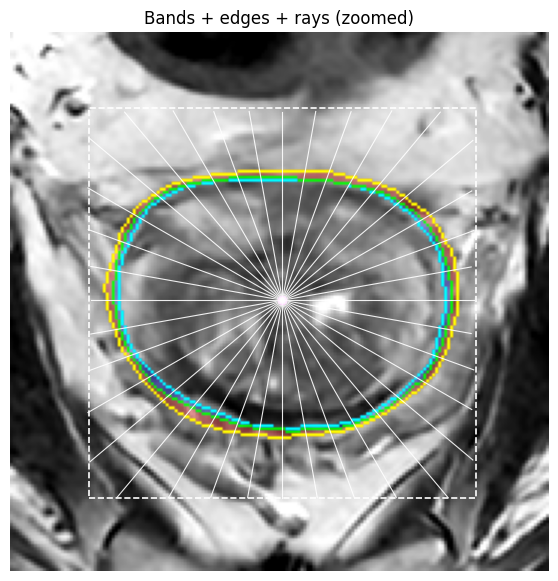

In [9]:
plot_rays_and_bands_zoom(
    seg=pred_mask[sl],
    unc_inner=unc_inner,
    unc_outer=unc_outer,
    unc_edge_inner=unc_edge_inner,
    unc_edge_outer=unc_edge_outer,
    img=img[sl],
    angle_step=10,
    zoom_size=180,
    pad=5,
)

In [10]:
def process_rays(
    angles,
    inner_length,
    outer_length,
    edge_length,
    seg_radius,
    center_yx,
    spacing_yx,
    diff_thresh=2.0,
):
    cy, cx = center_yx
    sy, sx = spacing_yx

    mask = edge_length >= min(sy,sx) #Make sure every edge is at least one pixel wide 

    #Filter all arrays to only include valid rays
    angles_filtered = angles[mask]
    inner_filtered = inner_length[mask]
    outer_filtered = outer_length[mask]
    edge_filtered = edge_length[mask]
    seg_radius_filtered = seg_radius[mask]

    #Compute differential between outer and inner lengths
    edge_differential = outer_filtered - inner_filtered

    prompts_pos = []
    prompts_neg = []

    for i in range(len(angles_filtered)):
        diff = edge_differential[i]

        if np.isnan(seg_radius_filtered[i]):
            continue

        #Compute direction of ray in image coords
        theta = np.deg2rad(angles_filtered[i])
        dy = np.sin(theta)
        dx = np.cos(theta)

        #In case of diagnosed undersegmentation
        if diff >= diff_thresh:
            
            #Positive prompt generation
            r_mm_pos = seg_radius_filtered[i] + 0.5 * outer_filtered[i] # FAR AWAY PROMPTING. WAS 0.5
            y_pos = cy + (r_mm_pos * dy) / sy
            x_pos = cx + (r_mm_pos * dx) / sx
            prompts_pos.append((y_pos, x_pos))

            #TODO: NEGTIVE PROMPT COUNTERPART GENERATION? Kan wellicht maar hoeft niet
            # r_mm_neg = seg_radius_filtered[i] + 6 * outer_filtered[i] # NIETJES PRINCIPE NEGATIVE COUNTERPROMPT REALLY FAR AWAY
            # y_neg = cy + (r_mm_neg * dy) / sy
            # x_neg = cx + (r_mm_neg * dx) / sx
            # prompts_neg.append((y_neg, x_neg))

        #In case of diagnosed oversegmentation
        elif diff <= -diff_thresh:
            
            #Negative prompt generation
            r_mm_neg = seg_radius_filtered[i] - 0.25 * inner_filtered[i]
            y_neg = cy + (r_mm_neg * dy) / sy
            x_neg = cx + (r_mm_neg * dx) / sx
            prompts_neg.append((y_neg, x_neg))

            #Positive prompt counterpart generation (NIETJES PRINCIPE)
            r_mm_pos = seg_radius_filtered[i] - inner_filtered[i]
            y_pos = cy + (r_mm_pos * dy) / sy
            x_pos = cx + (r_mm_pos * dx) / sx
            prompts_pos.append((y_pos, x_pos))

    return {
        "positive_prompts": np.array(prompts_pos),
        "negative_prompts": np.array(prompts_neg),
    }


In [ ]:
import numpy as np


def generate_and_save_ray_prompts(
    pred_mask_stack: np.ndarray,
    uncertainty_stack: np.ndarray,
    img_stack: np.ndarray,
    spacing,
    case_dir: Path,
    extract_bands_fn,
    raycast_fn,
    process_rays_fn,
    binary_threshold: float = 0.1,
    asymmetry_threshold: float = 2.0,
    edge_threshold: float = 0.4,
    angle_step: int = 5,
    step_mm: float = 0.2,
    make_debug_plots: bool = False,
    save_name: str | None = None,
):
    
    pred_mask_stack = np.asarray(pred_mask_stack).astype(bool)
    uncertainty_stack = np.asarray(uncertainty_stack)
    img_stack = np.asarray(img_stack)

    if pred_mask_stack.shape != uncertainty_stack.shape:
        raise ValueError("pred_mask_stack and uncertainty_stack must have the same shape.")
    if pred_mask_stack.shape != img_stack.shape:
        raise ValueError("pred_mask_stack and img_stack must have the same shape.")

    thresholded_unc = uncertainty_stack >= binary_threshold

    all_pos = []
    all_neg = []

    for z in range(pred_mask_stack.shape[0]):
        seg = pred_mask_stack[z]
        unc = thresholded_unc[z]
        img = img_stack[z]

        if not seg.any() or not unc.any():
            continue

        seg_edge, unc_inner, unc_outer, _, _ = extract_bands_fn(seg, unc)

        result = raycast_fn(
            seg=seg,
            unc_map=unc,
            unc_inner=unc_inner,
            seg_edge=seg_edge,
            unc_outer=unc_outer,
            pixel_spacing=spacing,
            angle_step=angle_step,
            step_mm=step_mm,
            debug_dir=(case_dir / "nnUNetOutput" / f"ray_debug_slice_{z:03d}") if make_debug_plots else None,
            background_image=img,
        )

        out = process_rays_fn(
            angles=result["angles_deg"],
            inner_length=result["inner_mm"],
            outer_length=result["outer_mm"],
            edge_length=result["edge_mm"],
            seg_radius=result["seg_radius_mm"],
            center_yx=result["center_of_mass_px"],
            spacing_yx=(spacing[1], spacing[2]),
            diff_thresh=asymmetry_threshold,
        )

        pos = np.asarray(out["positive_prompts"], dtype=np.float32)
        neg = np.asarray(out["negative_prompts"], dtype=np.float32)

        if len(pos):
            all_pos.append(np.column_stack([np.full(len(pos), z, dtype=np.float32), pos]))
        if len(neg):
            all_neg.append(np.column_stack([np.full(len(neg), z, dtype=np.float32), neg]))

    pos_all = np.concatenate(all_pos, axis=0) if all_pos else np.empty((0, 3), dtype=np.float32)
    neg_all = np.concatenate(all_neg, axis=0) if all_neg else np.empty((0, 3), dtype=np.float32)

    out_dir = case_dir / "nnUNetOutput"
    out_dir.mkdir(parents=True, exist_ok=True)

    if save_name is None:
        save_name = f"ray_prompts_thr{binary_threshold:.4f}_asym{asymmetry_threshold:.1f}.npz"

    out_path = out_dir / save_name

    np.savez_compressed(
        out_path,
        positive=pos_all.astype(np.float32),
        negative=neg_all.astype(np.float32),
        binary_threshold=np.float32(binary_threshold),
        asymmetry_threshold=np.float32(asymmetry_threshold),
        edge_threshold=np.float32(edge_threshold),
        angle_step=np.int32(angle_step),
        step_mm=np.float32(step_mm),
    )

    print(f"Saved prompts to: {out_path}")
    print(f"Positive prompts: {len(pos_all)}")
    print(f"Negative prompts: {len(neg_all)}")

    return pos_all, neg_all, out_path

: 

In [ ]:
pos_all, neg_all, out_path = generate_and_save_ray_prompts(
    pred_mask_stack=pred_mask,
    uncertainty_stack=uncertainty,
    img_stack=img,
    spacing=spacing,
    case_dir=case_dir,
    extract_bands_fn=extract_bands,
    raycast_fn=raycast_band_lengths_mm,
    process_rays_fn=process_rays,
    binary_threshold=0.1,
    asymmetry_threshold=2.0,
    angle_step=20,
    step_mm=0.2,
    make_debug_plots=False,
)

In [ ]:
def find_threshold_3d_simple(
    seg_3d,
    unc_3d,
    target_mm,
    spacing,
    step_fraction=0.02,
    angle_step=5,
    verbose=False,
):
    """
    Decrease threshold from max value until average band thickness >= target_mm
    """

    #Define maximum value for fractional downscaling
    max_val = float(np.max(unc_3d))
    step = step_fraction * max_val
    thr = max_val #Initially threshold from max value
    last_valid = None

    while thr > 0:
        band_values = []

        
        for z in range(seg_3d.shape[0]):
            #Skip empty slices
            seg = seg_3d[z]
            if not seg.any():
                continue
            unc_bin = unc_3d[z] >= thr
            if not unc_bin.any():
                continue

            #Extract band locations to determine thickness
            seg_edge, unc_inner, unc_outer, _, _ = extract_bands(seg, unc_bin)

            try:
                res = raycast_band_lengths_mm(
                    seg=seg,
                    unc_map=unc_bin,
                    unc_inner=unc_inner,
                    seg_edge=seg_edge,
                    unc_outer=unc_outer,
                    pixel_spacing=spacing,
                    angle_step=angle_step,
                    step_mm=None,
                )

                #Determine band thickness average across rays and slices
                band = np.mean(res["inner_mm"] + res["outer_mm"])
                band_values.append(band)

            except ValueError:
                continue

        #Checks if no valid bands were found for this threshold across the 3D volume
        if len(band_values) == 0:
            thr -= step
            continue

        #Computes average band thickness across all valid slices for this threshold
        avg_band = np.mean(band_values)

        if verbose:
            print(f"thr={thr:.6f} | band={avg_band:.2f} mm")

        last_valid = (thr, avg_band)

        if avg_band >= target_mm:
            return thr, avg_band

        thr -= step #Lower threshold

    return last_valid

In [ ]:
thr, band = find_threshold_3d_simple(
    seg_3d=pred_mask,
    unc_3d=uncertainty,
    target_mm=3.0,      # <-- choose your desired band thickness
    spacing=spacing,
)
thresholded_unc = uncertainty >= thr

thr=0.407207 | band=0.01 mm
thr=0.399063 | band=0.04 mm
thr=0.390919 | band=0.05 mm
thr=0.382775 | band=0.08 mm
thr=0.374630 | band=0.09 mm
thr=0.366486 | band=0.06 mm
thr=0.358342 | band=0.08 mm
thr=0.350198 | band=0.09 mm
thr=0.342054 | band=0.12 mm
thr=0.333910 | band=0.17 mm
thr=0.325766 | band=0.26 mm
thr=0.317621 | band=0.31 mm
thr=0.309477 | band=0.37 mm
thr=0.301333 | band=0.43 mm
thr=0.293189 | band=0.49 mm
thr=0.285045 | band=0.50 mm
thr=0.276901 | band=0.57 mm
thr=0.268757 | band=0.67 mm
thr=0.260612 | band=0.76 mm
thr=0.252468 | band=0.84 mm
thr=0.244324 | band=0.91 mm
thr=0.236180 | band=0.98 mm
thr=0.228036 | band=1.05 mm
thr=0.219892 | band=1.12 mm
thr=0.211748 | band=1.18 mm
thr=0.203603 | band=1.24 mm
thr=0.195459 | band=1.31 mm
thr=0.187315 | band=1.38 mm
thr=0.179171 | band=1.44 mm
thr=0.171027 | band=1.50 mm
thr=0.162883 | band=1.55 mm
thr=0.154739 | band=1.61 mm
thr=0.146595 | band=1.66 mm
thr=0.138450 | band=1.71 mm
thr=0.130306 | band=1.77 mm
thr=0.122162 | band=